# Portfolio Lab — robustness and out-of-sample validation

How stable is the optimized portfolio through time, and how does it perform genuinely out of sample? All calculations live in `portfolio_lab.robustness` and reuse the main engine.

| Analysis | Where | Nature |
|---|---|---|
| A. Full-sample optimization | `portfolio_analysis.ipynb` | Descriptive, in-sample |
| B. Subperiod stability | Section A below | Robustness diagnostic, **still in-sample** within each period |
| C. Walk-forward | Section B below | Genuine out-of-sample evaluation |

Out-of-sample results are for evaluation only: nothing here is tuned on them, and neither a good nor a bad result predicts future performance.

In [1]:
from pathlib import Path
from IPython.display import display
from portfolio_lab.config import load_config, configure_universe
from portfolio_lab.data import load_market_data, study_coverage
from portfolio_lab.leverage import add_leverage
from portfolio_lab.plotting import plot_oos_growth, plot_allocations, plot_effective_assets
from portfolio_lab.reporting import format_weights
from portfolio_lab.robustness import OPTIMIZED, subperiod_stability, walk_forward

project_dir = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

## Universe and data
Same universe, providers, EUR conversion, leverage and engine settings as `portfolio_analysis.ipynb`: both start from the package defaults in `load_config()`. To study a variant, override it here, e.g. `config = configure_universe(config, {...}, {...})`.

In [2]:
config = load_config(project_dir)
data = load_market_data(config)
prices, _ = add_leverage(data.common, data.native, data.fx, config)
display(study_coverage(data, config))

{'common_start': '2000-12-29',
 'common_end': '2026-10-02',
 'common_observations': 6403,
 'latest_raw_asset_start': '2000-12-29',
 'raw_start_limiting_assets': ['MSCI World'],
 'earliest_raw_asset_end': '2026-10-02',
 'raw_end_limiting_assets': ['Apple',
  'Nasdaq 100',
  'S&P 500',
  'Dow Jones',
  'Gold',
  'MSCI World',
  'Europe',
  'US Real Estate'],
 'latest_eur_asset_start': '2000-12-29',
 'eur_start_limiting_assets': ['MSCI World'],
 'start_limiting_series': ['MSCI World'],
 'fx_start': '1999-01-04',
 'first_common_date_delayed_by_calendar': False}

## A. Subperiod stability (in-sample — not out-of-sample)
The same engine is re-estimated independently on 2001–2010, 2011–2020 and 2021–latest, using only the common history actually available. Each period's weights are fitted *and* described on the same data. The question: do optimal allocations change drastically with the regime used for estimation?

In [3]:
subperiods = subperiod_stability(prices, config)
display(subperiods.periods)
display(format_weights(subperiods.weights))
display(subperiods.metrics)
display(subperiods.stability)

,First date,Last date,Return base date,Returns
Period,,,,
2001-01-02 - 2010-12-30,2001-01-02,2010-12-30,2000-12-29,2481
2011-01-03 - 2020-12-31,2011-01-03,2020-12-31,2010-12-30,2489
2021-01-04 - 2026-10-02,2021-01-04,2026-10-02,2020-12-31,1432


,,Apple,Nasdaq 100,S&P 500,Dow Jones,Gold,MSCI World,Europe,US Real Estate
Portfolio,Period,,,,,,,,
Maximum Sharpe,2001-01-02 - 2010-12-30,31.35%,0.00%,0.00%,0.00%,68.65%,0.00%,0.00%,0.00%
Minimum Volatility,2001-01-02 - 2010-12-30,0.00%,0.00%,0.00%,0.00%,53.91%,46.09%,0.00%,0.00%
Maximum Sharpe,2011-01-03 - 2020-12-31,33.65%,41.19%,0.00%,0.00%,25.16%,0.00%,0.00%,0.00%
Minimum Volatility,2011-01-03 - 2020-12-31,0.00%,0.00%,0.00%,0.00%,49.16%,50.84%,0.00%,0.00%
Maximum Sharpe,2021-01-04 - 2026-10-02,7.05%,0.00%,0.00%,0.00%,42.69%,50.27%,0.00%,0.00%
Minimum Volatility,2021-01-04 - 2026-10-02,0.00%,0.00%,0.00%,5.90%,35.57%,33.97%,17.56%,7.01%


,,CAGR,Volatility,Sharpe,Max Drawdown
Portfolio,Period,,,,
Maximum Sharpe,2001-01-02 - 2010-12-30,0.247751,0.181043,1.333062,-0.289745
Minimum Volatility,2001-01-02 - 2010-12-30,0.074987,0.127815,0.638762,-0.286127
Maximum Sharpe,2011-01-03 - 2020-12-31,0.207939,0.181133,1.147522,-0.244338
Minimum Volatility,2011-01-03 - 2020-12-31,0.079526,0.113355,0.740618,-0.217637
Maximum Sharpe,2021-01-04 - 2026-10-02,0.164076,0.115348,1.391451,-0.142321
Minimum Volatility,2021-01-04 - 2026-10-02,0.145892,0.109848,1.310291,-0.128905


Mean weight  Min weight    Max weight  \
Portfolio          Asset                                                    
Maximum Sharpe     Apple           2.401475e-01    0.070479  3.364538e-01   
                   Nasdaq 100      1.373040e-01    0.000000  4.119120e-01   
                   S&P 500         4.503865e-17    0.000000  9.703504e-17   
                   Dow Jones       0.000000e+00    0.000000  0.000000e+00   
                   Gold            4.549933e-01    0.251634  6.864906e-01   
                   MSCI World      1.675552e-01    0.000000  5.026656e-01   
                   Europe          8.942268e-18    0.000000  2.682680e-17   
                   US Real Estate  1.844626e-16    0.000000  3.896758e-16   
Minimum Volatility Apple           0.000000e+00    0.000000  0.000000e+00   
                   Nasdaq 100      1.504841e-17    0.000000  2.796375e-17   
                   S&P 500         8.517005e-18    0.000000  2.555101e-17   
                   Dow Jones       1.967750e-02    0.000000  5.903250e-02   
                   Gold            4.620870e-01    0.355650  5.390604e-01   
                   MSCI World      4.363569e-01    0.339681  5.084500e-01   
                   Europe          5.851783e-02    0.000000  1.755535e-01   
                   US Real Estate  2.336080e-02    0.000000  7.008239e-02   

                                     Std weight  Zero-weight share  
Portfolio          Asset                                            
Maximum Sharpe     Apple           1.473842e-01           0.000000  
                   Nasdaq 100      2.378175e-01           0.666667  
                   S&P 500         4.889026e-17           1.000000  
                   Dow Jones       0.000000e+00           1.000000  
                   Gold            2.187895e-01           0.000000  
                   MSCI World      2.902141e-01           0.666667  
                   Europe          1.548846e-17           1.000000  
                   US Real Estate  1.956649e-16           1.000000  
Minimum Volatility Apple           0.000000e+00           1.000000  
                   Nasdaq 100      1.410338e-17           1.000000  
                   S&P 500         1.475189e-17           1.000000  
                   Dow Jones       3.408243e-02           0.666667  
                   Gold            9.518853e-02           0.000000  
                   MSCI World      8.702848e-02           0.000000  
                   Europe          1.013558e-01           0.666667  
                   US Real Estate  4.046209e-02           0.666667

## B. Walk-forward out-of-sample
For each calendar test year: estimate Maximum Sharpe and Minimum Volatility on the previous **10 full years only** (expected returns, covariance and optimization all train-only), freeze the weights, then apply them to that test year only. Folds are generated from the actual common history; the last year may be incomplete (`complete_test_year`).

* Rebalancing semantics are the engine's: constant target weights, rebalanced to target at every common observation. Targets are re-estimated once a year.
* Equal Weight uses the same optimizer universe, same convention and annual boundaries; MSCI World is its realized EUR return.
* The performance curve is built exclusively from test-year returns.
* Turnover = 0.5 × Σ|w<sub>t</sub> − w<sub>t−1</sub>| between consecutive annual targets (first year: none). Concentration: HHI = Σw², effective number of assets = 1 / HHI.

In [4]:
wf = walk_forward(prices, config, train_years=10)
print(f"Covariance estimator: {wf.covariance_estimator}; expected-return estimator: "
      f"{wf.expected_return_estimator} (both fitted on each training window)")
display(wf.fold_table)
display(wf.metrics[["CAGR", "Volatility annualized", "Sharpe", "Max Drawdown"]])

,train_start,train_end,test_start,test_end,return_base,train_returns,test_returns,complete_test_year
test_year,,,,,,,,
2011,2001-01-02,2010-12-30,2011-01-03,2011-12-30,2000-12-29,2481,250,True
2012,2002-01-02,2011-12-30,2012-01-03,2012-12-31,2001-12-31,2487,248,True
2013,2003-01-02,2012-12-31,2013-01-02,2013-12-31,2002-12-31,2487,250,True
2014,2004-01-05,2013-12-31,2014-01-02,2014-12-31,2003-12-31,2489,249,True
2015,2005-01-03,2014-12-31,2015-01-02,2015-12-31,2004-12-30,2491,250,True
2016,2006-01-03,2015-12-31,2016-01-04,2016-12-30,2005-12-30,2495,250,True
2017,2007-01-03,2016-12-30,2017-01-03,2017-12-29,2006-12-29,2497,248,True
2018,2008-01-02,2017-12-29,2018-01-02,2018-12-31,2007-12-31,2495,247,True
2019,2009-01-02,2018-12-31,2019-01-02,2019-12-31,2008-12-31,2491,248,True


,CAGR,Volatility annualized,Sharpe,Max Drawdown
Maximum Sharpe,0.159516,0.173432,0.951370,-0.350978
Minimum Volatility,0.111328,0.116528,0.975895,-0.232677
Equal Weight,0.146992,0.153614,0.981429,-0.304525
MSCI World,0.120818,0.148600,0.852096,-0.337585


### Year-by-year out-of-sample comparison
Calendar-year compounding of the walk-forward test-year returns above (no in-sample data). Excess = Maximum Sharpe annual return − benchmark annual return. Win rate = wins / all years; ties are counted separately. The incomplete final year is kept and marked YTD.

In [ ]:
annual = wf.annual_comparison("Maximum Sharpe")  # vs Equal Weight and MSCI World
annual_table, annual_summary = annual.formatted()
display(annual_table)
display(annual_summary.T)

**Reading the results (data through 2026-10-02; Ledoit-Wolf covariance, sample-mean expected returns).** Against MSCI World, Maximum Sharpe's lead is fairly broad: it wins 12 of 16 years and the median annual excess (+6.8%) exceeds the mean (+4.8%). Against Equal Weight it is thin: 10 of 16 wins, and the two best years (2025, 2019) supply almost all of the summed annual excess (mean of the other 14 years ≈ +0.3%), while 2013 (−28% vs Equal Weight, ~60% gold) offsets most gains.

*Pre-specified experiment:* `expected_return_method="bayes_stein"` (Jorion 1986, fitted per training window, mean intensity 0.45) did not improve this: 8/16 wins vs Equal Weight, mean excess −0.3%, Sharpe 0.958 vs 0.953 (see README). These are historical descriptive statistics: no significance test is performed, nothing is tuned on them, and they say nothing about future years.

In [5]:
for name in OPTIMIZED:
    print(f"{name}: weights selected on training data, applied to the test year")
    display(format_weights(wf.weights[name]))
display(wf.stability)
display(wf.turnover)
display(wf.concentration)

Maximum Sharpe: weights selected on training data, applied to the test year


,Apple,Nasdaq 100,S&P 500,Dow Jones,Gold,MSCI World,Europe,US Real Estate
Test year,,,,,,,,
2011,31.35%,0.00%,0.00%,0.00%,68.65%,0.00%,0.00%,0.00%
2012,34.36%,0.00%,0.00%,0.00%,65.64%,0.00%,0.00%,0.00%
2013,40.77%,0.00%,0.00%,0.00%,59.23%,0.00%,0.00%,0.00%
2014,49.57%,0.00%,0.00%,0.00%,50.43%,0.00%,0.00%,0.00%
2015,45.85%,0.00%,0.00%,0.00%,54.15%,0.00%,0.00%,0.00%
2016,47.49%,0.00%,0.00%,1.52%,50.99%,0.00%,0.00%,0.00%
2017,47.16%,0.00%,0.00%,2.85%,49.99%,0.00%,0.00%,0.00%
2018,31.40%,19.58%,0.00%,6.37%,42.65%,0.00%,0.00%,0.00%
2019,36.59%,29.45%,0.00%,6.54%,27.41%,0.00%,0.00%,0.00%


Minimum Volatility: weights selected on training data, applied to the test year


,Apple,Nasdaq 100,S&P 500,Dow Jones,Gold,MSCI World,Europe,US Real Estate
Test year,,,,,,,,
2011,0.00%,0.00%,0.00%,0.00%,53.91%,46.09%,0.00%,0.00%
2012,0.00%,0.00%,0.00%,0.00%,50.76%,49.24%,0.00%,0.00%
2013,0.00%,0.00%,0.00%,0.00%,46.49%,53.51%,0.00%,0.00%
2014,0.00%,0.00%,0.00%,0.00%,42.35%,57.65%,0.00%,0.00%
2015,0.00%,0.00%,0.00%,0.00%,42.02%,57.98%,0.00%,0.00%
2016,0.00%,0.00%,0.00%,0.00%,43.40%,56.60%,0.00%,0.00%
2017,0.00%,0.00%,0.00%,0.00%,46.30%,53.70%,0.00%,0.00%
2018,0.00%,0.00%,0.00%,0.00%,46.44%,53.56%,0.00%,0.00%
2019,0.00%,0.00%,0.00%,0.00%,41.92%,58.08%,0.00%,0.00%


Mean weight  Min weight    Max weight  \
Portfolio          Asset                                                    
Maximum Sharpe     Apple           3.616382e-01    0.236705  4.956998e-01   
                   Nasdaq 100      1.229608e-01    0.000000  5.884164e-01   
                   S&P 500         3.322004e-17    0.000000  3.031889e-16   
                   Dow Jones       4.578527e-02    0.000000  2.838148e-01   
                   Gold            4.619326e-01    0.174879  6.864906e-01   
                   MSCI World      2.263671e-03    0.000000  3.621873e-02   
                   Europe          1.505344e-17    0.000000  7.627108e-17   
                   US Real Estate  5.419382e-03    0.000000  8.671011e-02   
Minimum Volatility Apple           3.312194e-18    0.000000  2.137986e-17   
                   Nasdaq 100      1.482191e-17    0.000000  6.670309e-17   
                   S&P 500         9.434612e-18    0.000000  8.424633e-17   
                   Dow Jones       1.725834e-17    0.000000  6.660984e-17   
                   Gold            4.851751e-01    0.419176  5.726073e-01   
                   MSCI World      4.957717e-01    0.337784  5.808238e-01   
                   Europe          1.885743e-02    0.000000  9.540988e-02   
                   US Real Estate  1.957710e-04    0.000000  3.132336e-03   

                                     Std weight  Zero-weight share  
Portfolio          Asset                                            
Maximum Sharpe     Apple           8.001310e-02             0.0000  
                   Nasdaq 100      1.725721e-01             0.4375  
                   S&P 500         7.569142e-17             1.0000  
                   Dow Jones       9.399612e-02             0.6250  
                   Gold            1.655051e-01             0.0000  
                   MSCI World      9.054683e-03             0.9375  
                   Europe          2.536836e-17             1.0000  
                   US Real Estate  2.167753e-02             0.9375  
Minimum Volatility Apple           6.276359e-18             1.0000  
                   Nasdaq 100      1.887758e-17             1.0000  
                   S&P 500         2.597400e-17             1.0000  
                   Dow Jones       2.212190e-17             1.0000  
                   Gold            5.383688e-02             0.0000  
                   MSCI World      8.284529e-02             0.0000  
                   Europe          3.513439e-02             0.7500  
                   US Real Estate  7.830840e-04             0.9375

,Maximum Sharpe,Minimum Volatility,Equal Weight
Test year,,,
2011,NaN,NaN,NaN
2012,0.030135,0.031446,0.0
2013,0.064049,0.042730,0.0
2014,0.088007,0.041362,0.0
2015,0.037188,0.003306,0.0
2016,0.031587,0.013796,0.0
2017,0.013299,0.028939,0.0
2018,0.230998,0.001494,0.0
2019,0.152351,0.045270,0.0


Maximum Sharpe                  Minimum Volatility                   \
                     HHI Effective assets                HHI Effective assets   
Test year                                                                       
2011            0.569557         1.755749           0.503051         1.987868   
2012            0.548894         1.821844           0.500116         1.999536   
2013            0.517041         1.934082           0.502466         1.990184   
2014            0.500037         1.999852           0.511698         1.954279   
2015            0.503443         1.986324           0.512731         1.950342   
2016            0.485758         2.058639           0.508709         1.965762   
2017            0.473117         2.113643           0.502745         1.989079   
2018            0.322885         3.097074           0.502528         1.989938   
2019            0.300083         3.332413           0.513065         1.949071   
2020            0.241286         4.144453           0.508898         1.965030   
2021            0.346192         2.888567           0.500143         1.999429   
2022            0.432846         2.310292           0.500091         1.999636   
2023            0.281419         3.553418           0.464730         2.151787   
2024            0.423306         2.362360           0.457662         2.185017   
2025            0.439721         2.274172           0.444470         2.249869   
2026            0.491475         2.034691           0.436490         2.291004   

          Equal Weight                   
                   HHI Effective assets  
Test year                                
2011             0.125              8.0  
2012             0.125              8.0  
2013             0.125              8.0  
2014             0.125              8.0  
2015             0.125              8.0  
2016             0.125              8.0  
2017             0.125              8.0  
2018             0.125              8.0  
2019             0.125              8.0  
2020             0.125              8.0  
2021             0.125              8.0  
2022             0.125              8.0  
2023             0.125              8.0  
2024             0.125              8.0  
2025             0.125              8.0  
2026             0.125              8.0

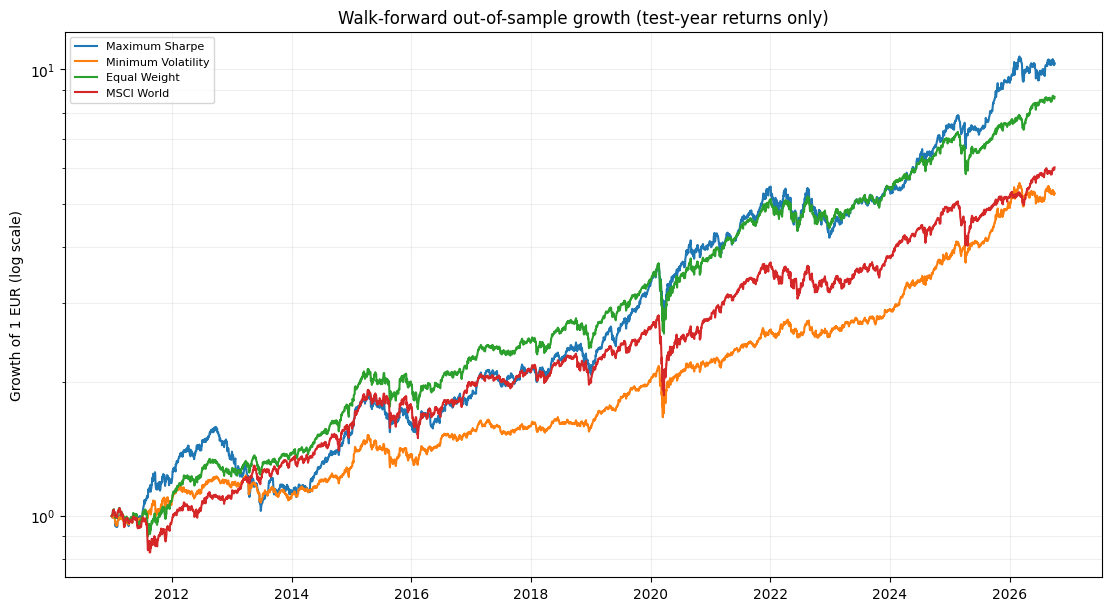

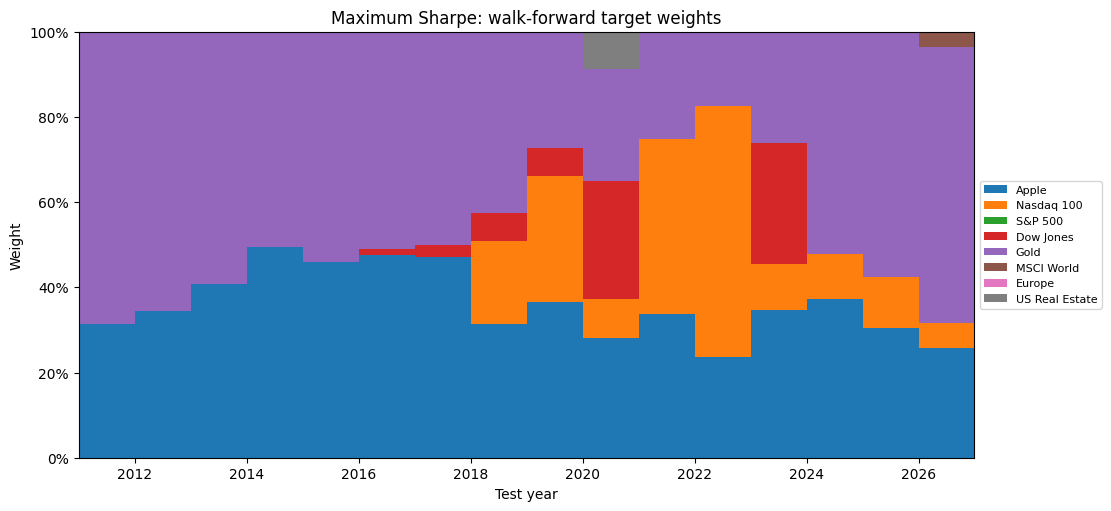

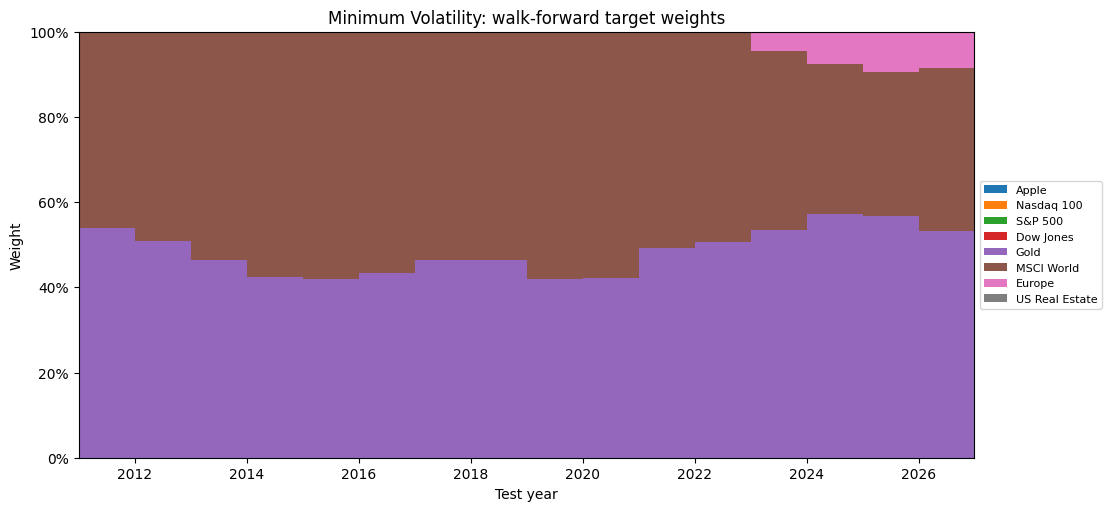

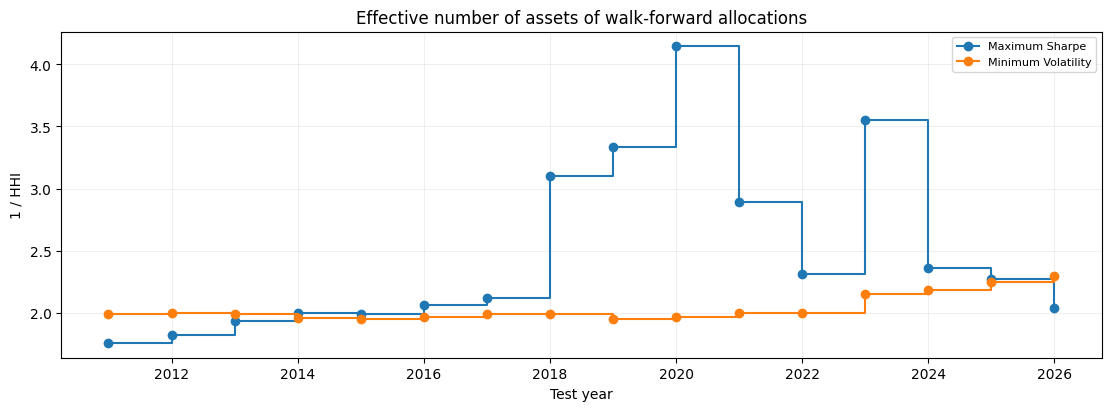

In [6]:
growth_figure = plot_oos_growth(wf.nav)
allocation_figures = [plot_allocations(wf.weights[name], f"{name}: walk-forward target weights")
                      for name in OPTIMIZED]
concentration_figure = plot_effective_assets(
    wf.concentration.xs("Effective assets", axis=1, level=1)[list(OPTIMIZED)])